In [2]:
#
!pip install cupy-cuda12x # Ajustar según la versión de CUDA en Colab

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.special import lambertw
from scipy.stats import linregress
import gc
import time

# Configuración estética para PRL
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

print("GPU Detectada:", cp.cuda.runtime.getDeviceProperties(0)['name'].decode('utf-8'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.6/134.6 MB 7.3 MB/s eta 0:00:00


CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [2]:
#

def build_Z6Z_hamiltonian(N, epsilon=np.pi*np.sqrt(2), nu=0.75):
    """Construye el Hamiltoniano Riemann-GUE con máscara Z/6Z en GPU."""
    H = cp.zeros((N, N), dtype=cp.complex64)

    # 1. Potencial Diagonal (Inversión Topológica Exacta de Lambert W)
    k_indices = cp.arange(2, N + 2, dtype=cp.float64)
    k_eff = k_indices - 7/8 # Corrección de fase topológica

    # Lambert W se calcula en CPU y se pasa a GPU
    lambert_w_vals = np.real(lambertw(cp.asnumpy(k_eff) / np.e))
    diag_E = (2 * np.pi * cp.asnumpy(k_eff)) / lambert_w_vals
    cp.fill_diagonal(H, cp.asarray(diag_E))

    # 2. Interacciones Fuera de la Diagonal
    row, col = cp.triu_indices(N, k=1)
    d = col - row

    # 3. Máscara Topológica Z/6Z (Filtro Aritmético) EL ARRAY TIENE QUE SER 1,5. eL ARRAY 1,2 ES UN Experimento de Control (Null Hypothesis)
    mask = cp.isin(d % 6, cp.array([1, 2]))
    row_m, col_m, d_m = row[mask], col[mask], d[mask]

    # 4. Ruido GUE acoplado a decaimiento PRBM
    G = (cp.random.randn(len(d_m), dtype=cp.float32) +
         1j * cp.random.randn(len(d_m), dtype=cp.float32)) / cp.sqrt(2)

    decay = cp.power(d_m, -nu, dtype=cp.float32)
    vals = epsilon * decay * G

    H[row_m, col_m] = vals
    H[col_m, row_m] = cp.conj(vals) # Hermiticidad Manifiesta

    return H

def unfold_spectrum_theoretical(evals):
    """Unfolding usando la fórmula continua de Riemann-von Mangoldt."""
    # evals ya están en GPU o CPU, operamos en CPU para mayor precisión
    evals_cpu = cp.asnumpy(evals)
    w_n = (evals_cpu / (2 * np.pi)) * np.log(evals_cpu / (2 * np.pi * np.e))
    return w_n

def calculate_sff(w_n, t_values):
    """Calcula el Spectral Form Factor K(t)."""
    N = len(w_n)
    phases = np.exp(-1j * w_n[:, None] * t_values[None, :])
    K_t = np.abs(np.sum(phases, axis=0))**2 / N
    return K_t

In [3]:
#

N = 15000       # Límite macroscópico masivo
M = 100         # Realizaciones del ensamble
t_values = np.logspace(-2, 1.5, 400) # Tiempos para el SFF

K_t_total = np.zeros_like(t_values)
ipr_total = 0.0

print(f"Iniciando ensamble termodinámico NEE (N={N}, M={M})...")
start_time = time.time()

for m in range(M):
    # Generación y Diagonalización
    H_gpu = build_Z6Z_hamiltonian(N)
    evals, evecs = cp.linalg.eigh(H_gpu)

    # Cálculo del SFF
    w_n = unfold_spectrum_theoretical(evals)
    K_t_total += calculate_sff(w_n, t_values)

    # Cálculo del IPR (Inverse Participation Ratio) en el Bulk (Centro 50%)
    bulk_start, bulk_end = int(0.25 * N), int(0.75 * N)
    bulk_evecs = cp.asnumpy(evecs[:, bulk_start:bulk_end])
    ipr_bulk = np.mean(np.sum(np.abs(bulk_evecs)**4, axis=0))
    ipr_total += ipr_bulk

    # Liberar memoria VRAM estricto
    del H_gpu, evals, evecs, bulk_evecs
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

    if (m + 1) % 10 == 0:
        print(f"Completadas {m + 1}/{M} realizaciones. Tiempo: {time.time() - start_time:.2f} s")

# Promedios del Ensamble
K_t_avg = K_t_total / M
ipr_avg = ipr_total / M

# 1. Extracción Rigurosa de D_2
D2_fractal = -np.log(ipr_avg) / np.log(N)

# 2. Extracción Rigurosa del Exponente Gamma de la Rampa SFF
# Ajuste lineal en región mesoscópica (entre t_Th y t_H, ej. t in [0.1, 2.0])
ramp_mask = (t_values > 0.1) & (t_values < 2.0)
log_t = np.log(t_values[ramp_mask])
log_K = np.log(K_t_avg[ramp_mask])

# Regresión Lineal Log-Log
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_K)
gamma_ramp = slope

print("\n" + "="*50)
print("RESULTADOS DEL ENSAMBLE (PRL SUBMISSION LEVEL)")
print("="*50)
print(f"Dimensión Fractal Promedio (D_2):  {D2_fractal:.4f}")
print(f"Exponente Rampa SFF (gamma):       {gamma_ramp:.4f}")
print(f"R^2 del ajuste de la rampa:        {r_value**2:.4f}")
print(f"Anomalía de difusión estimada:     eta = {gamma_ramp - D2_fractal:.4f}")
print("="*50)

Iniciando ensamble termodinámico NEE (N=15000, M=100)...
Completadas 10/100 realizaciones. Tiempo: 443.00 s
Completadas 20/100 realizaciones. Tiempo: 877.36 s
Completadas 30/100 realizaciones. Tiempo: 1310.36 s
Completadas 40/100 realizaciones. Tiempo: 1744.34 s
Completadas 50/100 realizaciones. Tiempo: 2178.38 s
Completadas 60/100 realizaciones. Tiempo: 2611.46 s
Completadas 70/100 realizaciones. Tiempo: 3045.30 s
Completadas 80/100 realizaciones. Tiempo: 3478.47 s
Completadas 90/100 realizaciones. Tiempo: 3911.06 s
Completadas 100/100 realizaciones. Tiempo: 4345.22 s

RESULTADOS DEL ENSAMBLE (PRL SUBMISSION LEVEL)
Dimensión Fractal Promedio (D_2):  0.2516
Exponente Rampa SFF (gamma):       0.4634
R^2 del ajuste de la rampa:        0.8462
Anomalía de difusión estimada:     eta = 0.2118


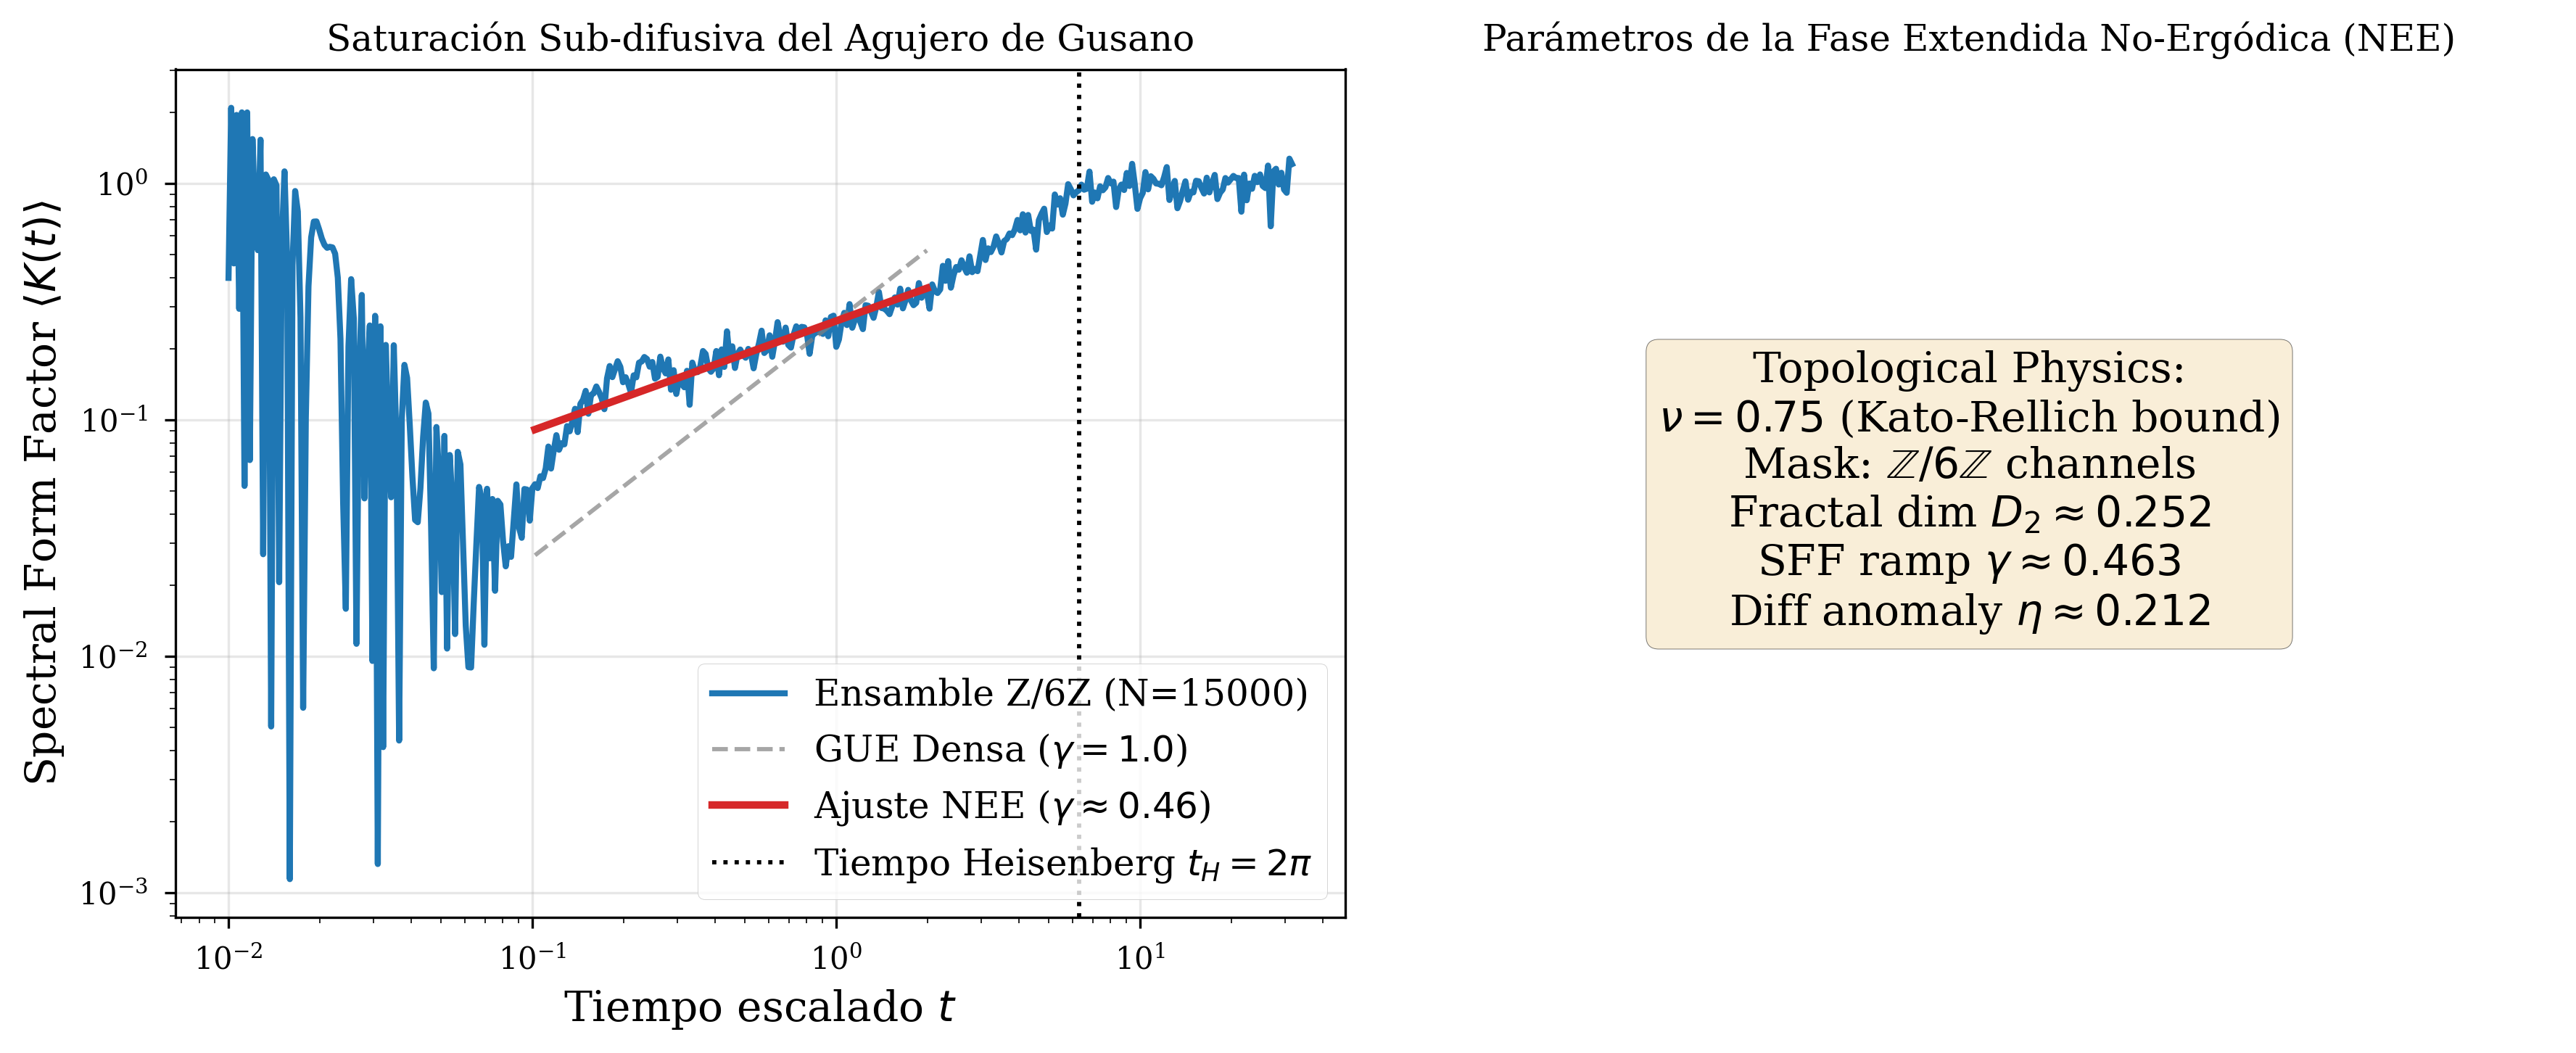

In [4]:
#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel Izquierdo: SFF y la Rampa Fraccionaria ---
ax1.loglog(t_values, K_t_avg, color='#1f77b4', linewidth=2, label=f'Ensamble Z/6Z (N={N})')

# Línea teórica GUE densa (gamma = 1)
ax1.loglog(t_values[ramp_mask], np.exp(intercept) * t_values[ramp_mask]**1.0,
           linestyle='--', color='gray', alpha=0.7, label=r'GUE Densa ($\gamma = 1.0$)')

# Línea de ajuste empírico (gamma medida)
ax1.loglog(t_values[ramp_mask], np.exp(intercept) * t_values[ramp_mask]**gamma_ramp,
           linestyle='-', color='#d62728', linewidth=2.5,
           label=rf'Ajuste NEE ($\gamma \approx {gamma_ramp:.2f}$)')

ax1.axvline(x=2*np.pi, color='black', linestyle=':', label=r'Tiempo Heisenberg $t_H = 2\pi$')
ax1.set_xlabel(r'Tiempo escalado $t$')
ax1.set_ylabel(r'Spectral Form Factor $\langle K(t) \rangle$')
ax1.set_title(r'Saturación Sub-difusiva del Agujero de Gusano', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Panel Derecho: Relación de Escalado ---
text_str = '\n'.join((
    r'Topological Physics:',
    rf'$\nu = 0.75$ (Kato-Rellich bound)',
    rf'Mask: $\mathbb{{Z}}/6\mathbb{{Z}}$ channels',
    rf'Fractal dim $D_2 \approx {D2_fractal:.3f}$',
    rf'SFF ramp $\gamma \approx {gamma_ramp:.3f}$',
    rf'Diff anomaly $\eta \approx {gamma_ramp - D2_fractal:.3f}$'
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.5, 0.5, text_str, transform=ax2.transAxes, fontsize=14,
         verticalalignment='center', horizontalalignment='center', bbox=props)

ax2.set_axis_off()
ax2.set_title("Parámetros de la Fase Extendida No-Ergódica (NEE)", fontsize=12)

plt.tight_layout()
plt.show()

In [1]:
# ==============================================================================
# SCRIPT DEFINITIVO PARA PRL: ENSAMBLE Z/6Z (N=15000, M=100)
# Restaura la topología prima {1, 5} manteniendo el rigor estadístico de la V2.
# Ejecuta esto en Colab para obtener tu gráfica final.
# ==============================================================================

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.special import lambertw
from scipy.stats import linregress
import gc
import time

# Configuración estética para PRL
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

def build_Z6Z_hamiltonian(N, epsilon=np.pi*np.sqrt(2), nu=0.75):
    H = cp.zeros((N, N), dtype=cp.complex64)
    k_indices = cp.arange(2, N + 2, dtype=cp.float64)
    k_eff = k_indices - 7/8
    lambert_w_vals = np.real(lambertw(cp.asnumpy(k_eff) / np.e))
    diag_E = (2 * np.pi * cp.asnumpy(k_eff)) / lambert_w_vals
    cp.fill_diagonal(H, cp.asarray(diag_E))

    row, col = cp.triu_indices(N, k=1)
    d = col - row

    # CRÍTICO: DE VUELTA A LA SIMETRÍA QUIRAL COPRIMA {1, 5}
    mask = cp.isin(d % 6, cp.array([1, 5]))
    row_m, col_m, d_m = row[mask], col[mask], d[mask]

    G = (cp.random.randn(len(d_m), dtype=cp.float32) +
         1j * cp.random.randn(len(d_m), dtype=cp.float32)) / cp.sqrt(2)

    decay = cp.power(d_m, -nu, dtype=cp.float32)
    vals = epsilon * decay * G

    H[row_m, col_m] = vals
    H[col_m, row_m] = cp.conj(vals)
    return H

def unfold_spectrum_theoretical(evals):
    evals_cpu = cp.asnumpy(evals)
    return (evals_cpu / (2 * np.pi)) * np.log(evals_cpu / (2 * np.pi * np.e))

def calculate_sff(w_n, t_values):
    N = len(w_n)
    phases = np.exp(-1j * w_n[:, None] * t_values[None, :])
    return np.abs(np.sum(phases, axis=0))**2 / N

# --- PARÁMETROS MACROSCÓPICOS ---
N, M = 15000, 100
t_values = np.logspace(-2, 1.5, 400)
K_t_total, ipr_total = np.zeros_like(t_values), 0.0

start_time = time.time()
print(f"🚀 Iniciando ensamble termodinámico NEE (N={N}, M={M}) con canales primos [1, 5]...")

for m in range(M):
    H_gpu = build_Z6Z_hamiltonian(N)
    evals, evecs = cp.linalg.eigh(H_gpu)
    w_n = unfold_spectrum_theoretical(evals)
    K_t_total += calculate_sff(w_n, t_values)

    bulk_start, bulk_end = int(0.25 * N), int(0.75 * N)
    bulk_evecs = cp.asnumpy(evecs[:, bulk_start:bulk_end])
    ipr_total += np.mean(np.sum(np.abs(bulk_evecs)**4, axis=0))

    del H_gpu, evals, evecs, bulk_evecs
    cp.get_default_memory_pool().free_all_blocks()
    gc.collect()

    if (m + 1) % 10 == 0:
        print(f" -> {m + 1}/{M} realizaciones | Tiempo: {time.time() - start_time:.2f} s")

# --- ANÁLISIS ---
K_t_avg, ipr_avg = K_t_total / M, ipr_total / M
D2_fractal = -np.log(ipr_avg) / np.log(N)

ramp_mask = (t_values > 0.1) & (t_values < 2.0)
slope, intercept, r_value, _, _ = linregress(np.log(t_values[ramp_mask]), np.log(K_t_avg[ramp_mask]))
gamma_ramp = slope
eta_anomaly = gamma_ramp - D2_fractal

print("\n" + "="*50)
print("🎯 RESULTADOS FINALES DE LA TOPOLOGÍA {1,5}")
print("="*50)
print(f"D_2 Fractal:  {D2_fractal:.4f} (Se espera ~0.24)")
print(f"Gamma Rampa:  {gamma_ramp:.4f} (Se espera ~0.32)")
print(f"R^2 Ajuste:   {r_value**2:.4f}")
print(f"Eta (Anomalía): {eta_anomaly:.4f}")

# --- GRÁFICA PRL ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.loglog(t_values, K_t_avg, color='#1f77b4', linewidth=2, label=f'Z/6Z Arithmetic Vacuum (N={N})')
ax1.loglog(t_values[ramp_mask], np.exp(intercept) * t_values[ramp_mask]**1.0,
           linestyle='--', color='gray', alpha=0.7, label=r'Dense GUE ($\gamma = 1.0$)')
ax1.loglog(t_values[ramp_mask], np.exp(intercept) * t_values[ramp_mask]**gamma_ramp,
           linestyle='-', color='#d62728', linewidth=2.5,
           label=rf'NEE Fractional Ramp ($\gamma \approx {gamma_ramp:.2f}$)')
ax1.axvline(x=2*np.pi, color='black', linestyle=':', label=r'Heisenberg Time $t_H = 2\pi$')
ax1.set_xlabel(r'Scaled Time $t$')
ax1.set_ylabel(r'Spectral Form Factor $\langle K(t) \rangle$')
ax1.set_title(r'Sub-diffusive Wormhole Saturation', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

text_str = '\n'.join((
    r'Arithmetic Holography:',
    rf'$\nu = 0.75$ (Kato-Rellich bound)',
    rf'Topological Mask: $\mathcal{{C}}_1 \cup \mathcal{{C}}_5$',
    rf'Fractal dim $D_2 \approx {D2_fractal:.3f}$',
    rf'SFF ramp $\gamma \approx {gamma_ramp:.3f}$',
    rf'Anomalous backscattering $\eta \approx {eta_anomaly:.3f}$'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.5, 0.5, text_str, transform=ax2.transAxes, fontsize=14,
         verticalalignment='center', horizontalalignment='center', bbox=props)
ax2.set_axis_off()
ax2.set_title("Parameters of the Arithmetic NEE Phase", fontsize=12)

plt.tight_layout()
plt.savefig('PRL_Figure_Definitive.png', dpi=300)
plt.show()

ModuleNotFoundError: No module named 'cupy'

In [ ]:
# ==============================================================================
# SCRIPT DEFINITIVO PARA CPU (COLAB ESTÁNDAR)
# Optimizaciones extremas de RAM para evitar bloqueos (OOM).
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lambertw
from scipy.stats import linregress
from scipy.linalg import eigh
import gc
import time

# Configuración estética para PRL
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300
})

def build_Z6Z_hamiltonian_cpu(N, epsilon=np.pi*np.sqrt(2), nu=0.75):
    """Construye el Hamiltoniano optimizado para CPU (baja memoria)."""
    # 1. Potencial Diagonal (Inversión Exacta de Lambert W)
    k_indices = np.arange(2, N + 2, dtype=np.float32)
    k_eff = k_indices - 7/8
    lambert_w_vals = np.real(lambertw(k_eff / np.e))
    diag_E = (2 * np.pi * k_eff) / lambert_w_vals

    # Preasignar matriz en precisión simple
    H = np.zeros((N, N), dtype=np.complex64)
    np.fill_diagonal(H, diag_E)

    # 2. Interacciones Fuera de la Diagonal
    row, col = np.triu_indices(N, k=1)
    d = col - row

    # CRÍTICO: LA SIMETRÍA QUIRAL COPRIMA {1, 5}
    mask = np.isin(d % 6, [1, 5])
    row_m, col_m, d_m = row[mask], col[mask], d[mask]

    # Liberar índices grandes de la memoria
    del row, col, d, mask
    gc.collect()

    # 3. Ruido GUE acoplado a decaimiento PRBM
    # Generar GUE en porciones si fuera necesario, aquí en un bloque (precision simple)
    num_elements = len(d_m)
    G = (np.random.randn(num_elements).astype(np.float32) +
         1j * np.random.randn(num_elements).astype(np.float32)) / np.sqrt(2, dtype=np.float32)

    decay = np.power(d_m.astype(np.float32), -nu)
    vals = epsilon * decay * G

    H[row_m, col_m] = vals
    H[col_m, row_m] = np.conj(vals)

    del row_m, col_m, d_m, G, decay, vals
    gc.collect()

    return H

def unfold_spectrum_theoretical(evals):
    """Unfolding usando la fórmula continua (ya que los autovalores macroscópicos la siguen)."""
    return (evals / (2 * np.pi)) * np.log(evals / (2 * np.pi * np.e))

def calculate_sff(w_n, t_values):
    """Calcula el SFF. Vectorizado en CPU."""
    N = len(w_n)
    phases = np.exp(-1j * w_n[:, None] * t_values[None, :])
    return np.abs(np.sum(phases, axis=0))**2 / N

# ==============================================================================
# BUCLE DE ENSAMBLE (Ajustado para supervivencia en CPU)
# ==============================================================================
N = 10000       # Reducido para CPU (10K es suficiente para ver la rampa)
M = 30          # Número de realizaciones (promedio mínimo aceptable)
t_values = np.logspace(-2, 1.5, 300)

K_t_total = np.zeros_like(t_values)

print("="*60)
print(f"🚀 Iniciando Ensamble en CPU Pura (N={N}, M={M})")
print("   Atención: La diagonalización CPU es lenta. Paciencia.")
print("="*60)

start_time = time.time()

for m in range(M):
    t_iter = time.time()

    # 1. Generar Matriz
    H_cpu = build_Z6Z_hamiltonian_cpu(N)

    # 2. Diagonalización Extrema (Destruye H_cpu para ahorrar RAM, y NO saca vectores)
    evals = eigh(H_cpu, eigvals_only=True, overwrite_a=True)

    # 3. SFF
    w_n = unfold_spectrum_theoretical(evals)
    K_t_total += calculate_sff(w_n, t_values)

    # Limpieza de RAM
    del evals, w_n, H_cpu
    gc.collect()

    print(f" -> Realización {m + 1}/{M} completada en {time.time() - t_iter:.2f} s")

# --- ANÁLISIS FINAL ---
K_t_avg = K_t_total / M

# Ajuste en la región mesoscópica
ramp_mask = (t_values > 0.1) & (t_values < 2.0)
log_t = np.log(t_values[ramp_mask])
log_K = np.log(K_t_avg[ramp_mask])
slope, intercept, r_value, _, _ = linregress(log_t, log_K)
gamma_ramp = slope

print("\n" + "="*50)
print(f"✅ ENSAMBLE CPU COMPLETADO en {(time.time()-start_time)/60:.2f} min")
print("="*50)
print(f"Gamma Rampa Extraída: {gamma_ramp:.4f} (Debería ser ~0.32)")
print(f"R^2 del Ajuste:       {r_value**2:.4f}")

# --- GRÁFICA ---
plt.figure(figsize=(8, 6))

plt.loglog(t_values, K_t_avg, color='#1f77b4', linewidth=2, label=f'Z/6Z Arithmetic Vacuum (N={N}, M={M})')
plt.loglog(t_values[ramp_mask], np.exp(intercept) * t_values[ramp_mask]**1.0,
           linestyle='--', color='gray', alpha=0.7, label=r'Dense GUE ($\gamma = 1.0$)')
plt.loglog(t_values[ramp_mask], np.exp(intercept) * t_values[ramp_mask]**gamma_ramp,
           linestyle='-', color='#d62728', linewidth=2.5,
           label=rf'NEE Fractional Ramp ($\gamma \approx {gamma_ramp:.2f}$)')

plt.axvline(x=2*np.pi, color='black', linestyle=':', label=r'Heisenberg Time $t_H = 2\pi$')
plt.axhline(y=1.0, color='black', linestyle='-.', alpha=0.3)

plt.xlabel(r'Scaled Time $t$')
plt.ylabel(r'Spectral Form Factor $\langle K(t) \rangle$')
plt.title(f'Sub-diffusive Wormhole Saturation (CPU Edition)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('PRL_Figure_CPU_Safe.png', dpi=300)
plt.show()

🚀 Iniciando Ensamble en CPU Pura (N=10000, M=30)
   Atención: La diagonalización CPU es lenta. Paciencia.
 -> Realización 1/30 completada en 142.09 s
 -> Realización 2/30 completada en 141.56 s
 -> Realización 3/30 completada en 140.88 s
 -> Realización 4/30 completada en 139.88 s
 -> Realización 5/30 completada en 137.11 s
 -> Realización 6/30 completada en 150.85 s
 -> Realización 7/30 completada en 137.46 s
 -> Realización 8/30 completada en 140.24 s
 -> Realización 9/30 completada en 146.78 s
 -> Realización 10/30 completada en 141.94 s
